In [178]:
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

import numpy as np
import arc
import pairinteraction as pi
if pi.Database.get_global_database() is None:
    pi.Database.initialize_global_database(download_missing=True)
import os
from IPython.display import Latex
import scipy
import pandas as pd
from pandas import DataFrame
import sys
sys.path.append(os.path.abspath("C:\\Users\\Tommy\\OneDrive - Durham University\\level 4 Project\\Code Directory\\L4-code-directory-2"))
from my_functions import *
h = scipy.constants.h
epsilon_0 = scipy.constants.epsilon_0
a_0 = scipy.constants.physical_constants['Bohr radius']
e = scipy.constants.e


In [179]:
from pairinteraction.visualization.colormaps import alphamagma
import os
colours = ('orange', 'green', 'red', 'blue')
orbs = ('s', 'p', 'd', 'f')

atom1 = 'Rb'
atom2 ='Cs'
l1_0, l2_0 = 2, 2
l1_1, l2_1 = 1, 3
j1_0, j2_0 = 3/2, 5/2



if atom1 == 'Rb':
    arc_atom1 = arc.Rubidium()
elif atom1 == 'Cs':
    arc_atom1 = arc.Caesium()
if atom2 == 'Rb':
    arc_atom2 = arc.Rubidium()
elif atom2 == 'Cs':
    arc_atom2 = arc.Caesium()  

energy_unit = 'MHz'
    

In [180]:
n_dif=2
ldif=1
jdif=1
def get_system_pair_list_theta(
    ket1: pi.SystemAtom, ket2: pi.SystemAtom, es: np.ndarray, erange, r, theta, b
) -> list[pi.SystemPair]:

    basis1 = pi.BasisAtom(ket1.species, n=(ket1.n-n_dif, ket1.n+n_dif), l=(0,ket1.l+ldif), j=(1/2,ket1.j+jdif))
    basis2 = pi.BasisAtom(ket2.species, n=(ket2.n-n_dif, ket2.n+n_dif), l=(0,ket2.l+ldif), j=(1/2,ket2.j+jdif))

    

    pair_systems = []
    for i, e in enumerate(es):
                
        # print(f'pair energy = {pair_energy}{energy_unit}')
        system1, system2 = pi.SystemAtom(basis1).set_magnetic_field([0,0,b], unit='G').set_electric_field([0,0,e], unit='V/cm').set_diamagnetism_enabled(True), pi.SystemAtom(basis2).set_magnetic_field([0,0,b], unit='G').set_electric_field([0,0,e], unit='V/cm').set_diamagnetism_enabled(True)


        pi.diagonalize([system1, system2])

        pair_energy = system1.get_corresponding_energy(ket1, unit=energy_unit) + system2.get_corresponding_energy(ket2, unit=energy_unit)
        min_energy, max_energy = pair_energy - erange, pair_energy + erange

        pair_basis = pi.BasisPair(
            [system1, system2], energy=(min_energy, max_energy), energy_unit=energy_unit
        )
        
        pair_systems.append(
            pi.SystemPair(pair_basis)
            .set_distance(r, unit='um', angle_degree=theta)
            )
        states_num = pair_basis.number_of_states
        # print(f"Number of two-atom basis states: {pair_basis.number_of_states}")


    # Diagonalize the systems in parallel
    pi.diagonalize(
        pair_systems,
        diagonalizer="eigen",
        energy_range=(min_energy, max_energy),
        energy_range_unit=energy_unit,
    )
    
    energies = [system.get_eigenenergies(unit = energy_unit) - pair_energy for system in pair_systems]

    return pair_systems, states_num, energies


In [181]:
channels = channels_import(atom1, l1_0, j1_0, atom2, l2_0, j2_0, l1_1, l2_1)

   Unnamed: 0  n1_0  l1_0  j1_0  n2_0  l2_0  j2_0  n1_1  l1_1  j1_1  ...  \
0           3    45     2   1.5    51     2   2.5    46     1   0.5  ...   
1           2    45     2   1.5    51     2   2.5    46     1   0.5  ...   
2           6    47     2   1.5    54     2   2.5    48     1   1.5  ...   
3           4    53     2   1.5    60     2   2.5    54     1   0.5  ...   
4           5    53     2   1.5    60     2   2.5    54     1   0.5  ...   
5           8    54     2   1.5    62     2   2.5    55     1   1.5  ...   
6           0    59     2   1.5    57     2   2.5    61     1   0.5  ...   
7           1    59     2   1.5    57     2   2.5    61     1   0.5  ...   
8           7    61     2   1.5    69     2   2.5    62     1   0.5  ...   

   asymmetry 4um  energy 4um  asymmetry 3um  energy 3um  energy_Rb 3um  \
0    -583.190951  -34.489343     -28.409727  -93.572437     -11.269094   
1    -472.400891  -34.617153     -47.273165  -94.268968      -4.130529   
2     -89.981441 

In [182]:
channel = 3
c = channels.loc[channel]
# set atom properties
n1_0, l1_0, j1_0 = int(c['n1_0']), int(c['l1_0']), c['j1_0']
n2_0, l2_0, j2_0 = int(c['n2_0']), int(c['l2_0']), c['j2_0'] 
mj1_0s, mj2_0s = np.arange(-j1_0, j1_0+1), np.arange(-j2_0, j2_0+1)
f1_0, f2_0 = 1, 1

n1_1, l1_1, j1_1 = int(c['n1_1']), int(c['l1_1']), c['j1_1']
n2_1, l2_1, j2_1 =  int(c['n2_1']), int(c['l2_1']), c['j2_1']
f1_1, f2_1 = 1, 1

btunes = np.unique(magTune_import(atom1, n1_0, l1_0, j1_0, atom2, n2_0, l2_0, j2_0, l1_1, l2_1))

ket1 = pi.KetAtom(atom1, n=n1_0, l=l1_0, m=j1_0, j=j1_0)
ket2 = pi.KetAtom(atom2, n=n2_0, l=l2_0, m=j2_0, j=j2_0)
ket1_1 = pi.KetAtom(atom1, n=n1_1, l=l1_1, j=j1_1, m=j1_1)
ket2_1 = pi.KetAtom(atom2, n=n2_1, l=l2_1, j=j2_1, m=j2_1)
ket1_energy = ket1.get_energy(unit=energy_unit)
ket2_energy = ket2.get_energy(unit=energy_unit)

defect = c['defect']


bfield = 0  # Gauss


print(defect)

Magnetic file doesn't exist
-4.618507926352301


In [192]:
theta = 0
b=2
es = np.linspace(0, .8 ,500)

rs=[3,5000]
erange = abs(defect * 1000)
print(btunes)

[None]


In [193]:
system_pairs_dict: dict[float, list[pi.SystemPair]] = {}
ket1, ket2 = pi.KetAtom(atom1, n=n1_0, l=l1_0, j=j1_0, m=-j1_0), pi.KetAtom(atom2, n=n2_0, l=l2_0, j=j2_0, m=-j2_0)
system_pairs_dict_inter = {}
system_pairs_dict_Rb = {}
system_pairs_dict_Cs = {}
energies_inter_dict = {}
energies_intra_Rb_dict = {}
energies_intra_Cs_dict = {}
for r in rs:
    while True:
        try:
            pairs = get_system_pair_list_theta(ket1, ket2, es, erange, r, theta, b)
            system_pairs = pairs[0]
            states_num = pairs[1]
            energies = pairs[2]
            
            system_pairs_dict_inter.update({f'{theta}{r}': system_pairs})
            energies_inter_dict.update({f'{theta}{r}' : energies})
            break
        except RuntimeError: # Replace Exception with something more specific.
            continue
    

print(system_pairs)


[SystemPair(BasisPair(|~Rb:53,P_1/2,-1/2; ~Cs:62,D_3/2,-3/2⟩ ... |Rb:53,F_5/2,5/2; ~Cs:60,S_1/2,1/2⟩), is_diagonal=True), SystemPair(BasisPair(|~Rb:53,P_1/2,-1/2; ~Cs:62,D_3/2,-3/2⟩ ... |~Rb:53,F_5/2,5/2; ~Cs:60,S_1/2,1/2⟩), is_diagonal=True), SystemPair(BasisPair(|~Rb:53,P_1/2,-1/2; ~Cs:62,D_3/2,-3/2⟩ ... |~Rb:53,F_5/2,5/2; ~Cs:60,S_1/2,1/2⟩), is_diagonal=True), SystemPair(BasisPair(|~Rb:53,P_1/2,-1/2; ~Cs:62,D_3/2,-3/2⟩ ... |~Rb:53,F_5/2,5/2; ~Cs:60,S_1/2,1/2⟩), is_diagonal=True), SystemPair(BasisPair(|~Rb:53,P_1/2,-1/2; ~Cs:62,D_3/2,-3/2⟩ ... |~Rb:53,F_5/2,5/2; ~Cs:60,S_1/2,1/2⟩), is_diagonal=True), SystemPair(BasisPair(|~Rb:53,P_1/2,-1/2; ~Cs:62,D_3/2,-3/2⟩ ... |~Rb:53,F_5/2,5/2; ~Cs:60,S_1/2,1/2⟩), is_diagonal=True), SystemPair(BasisPair(|~Rb:53,P_1/2,-1/2; ~Cs:62,D_3/2,-3/2⟩ ... |~Rb:53,F_5/2,5/2; ~Cs:60,S_1/2,1/2⟩), is_diagonal=True), SystemPair(BasisPair(|~Rb:53,P_1/2,-1/2; ~Cs:62,D_3/2,-3/2⟩ ... |~Rb:53,F_5/2,5/2; ~Cs:60,S_1/2,1/2⟩), is_diagonal=True), SystemPair(BasisPair(|~R

In [194]:
import os
datapath = fr'C:\\Users\\tommy\\OneDrive - Durham University\\level 4 Project\\Data\\interesting channels\\{atom1}{atom2}\\{n1_0}{orbs[l1_0]}{j1_0} {n2_0}{orbs[l2_0]}{j2_0}\\energy electric\\inter intra\\'
if not os.path.exists(datapath + 'inter'):
    os.makedirs(datapath + 'inter')


energies_inter_dict.update({'es' : es})


    

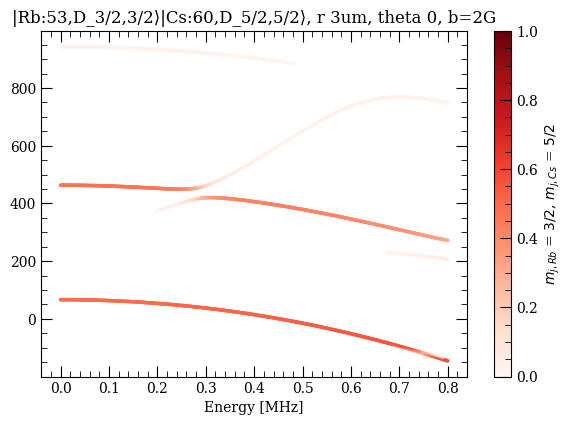

[np.float64(943.4538314342499), np.float64(463.4749310016632), np.float64(66.7204020023346), np.float64(943.4532046318054), np.float64(463.47413778305054), np.float64(66.71959710121155), np.float64(943.4513516426086), np.float64(463.47182035446167), np.float64(66.71711015701294), np.float64(943.4482588768005), np.float64(463.4679322242737), np.float64(66.71299290657043), np.float64(943.4439280033112), np.float64(463.4625241756439), np.float64(66.70719003677368), np.float64(943.4383668899536), np.float64(463.4555821418762), np.float64(66.69971680641174), np.float64(943.4315655231476), np.float64(463.44708013534546), np.float64(66.69060277938843), np.float64(943.4235277175903), np.float64(463.43703293800354), np.float64(66.6798324584961), np.float64(943.4142537117004), np.float64(463.4254410266876), np.float64(66.66740489006042), np.float64(943.4037415981293), np.float64(463.4123055934906), np.float64(66.6533203125), np.float64(943.3919942378998), np.float64(463.3976294994354), np.float6

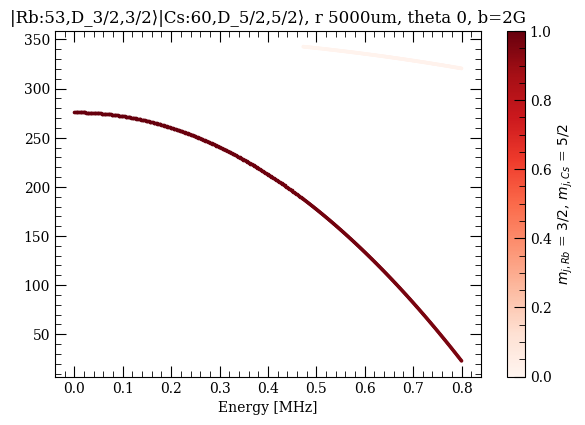

[np.float64(275.8727731704712), np.float64(275.87176990509033), np.float64(275.8687605857849), np.float64(275.86374497413635), np.float64(275.8567228317261), np.float64(275.84769463539124), np.float64(275.8366599082947), np.float64(275.8236184120178), np.float64(275.808571100235), np.float64(275.79151701927185), np.float64(275.7724561691284), np.float64(275.75138878822327), np.float64(275.7283148765564), np.float64(275.70323419570923), np.float64(275.67614674568176), np.float64(275.6470522880554), np.float64(275.6159510612488), np.float64(275.5828421115875), np.float64(275.547726392746), np.float64(275.5106031894684), np.float64(275.47147250175476), np.float64(275.4303340911865), np.float64(275.38718843460083), np.float64(275.3420341014862), np.float64(275.29487204551697), np.float64(275.24570202827454), np.float64(275.1945233345032), np.float64(275.14133620262146), np.float64(275.08614110946655), np.float64(275.0289361476898), np.float64(274.9697229862213), np.float64(274.908500194549

In [195]:
import os
figpath = fr'C:\\Users\\tommy\\OneDrive - Durham University\\level 4 Project\\Figures\\interesting channels\\{atom1}{atom2}\\{n1_0}{orbs[l1_0]}{j1_0} {n2_0}{orbs[l2_0]}{j2_0}\\energy electric\\inter intra\\'
if not os.path.exists(figpath):
    os.makedirs(figpath)

# ax.set_ylim(-0.01, 0.01)

prop_cycle = plt.rcParams['axes.prop_cycle']
colours = prop_cycle.by_key()['color']
# r=10
# b=5
for r in rs:
    for mj1 in mj1_0s[-1:]:
        for mj2 in mj2_0s[-1:]:
            import os

            ket1, ket2 = pi.KetAtom(atom1, n=n1_0, l=l1_0, j=j1_0, m=mj1), pi.KetAtom(atom2, n=n2_0, l=l2_0, j=j2_0, m=mj2)

            system_pairs = system_pairs_dict_inter[f'{theta}{r}']

            overlaps_inter = [system.get_eigenbasis().get_overlaps([ket1, ket2]) for system in system_pairs]


            energies_inter = energies_inter_dict[f'{theta}{r}']


            # print(energies_inter)
            
                    
            # 2. Build the RGBA array: (N, 4)

            fig, ax = plt.subplots(ncols=1, figsize=(6, 4))

            plt.tight_layout()
            plt.title(fr'{str(ket1)}{str(ket2)}, r {r}um, theta {theta}, b={b}G')
            energy_lim = abs(defect + defect*2)
            offset=defect/2
            min_energy = -energy_lim+offset
            max_energy = energy_lim+offset
            # plt.ylim(min_energy, max_energy)
            # plt.xlim(2, 2.7)
            # plt.ylabel(f"Energy [{energy_unit}]")
            plt.xlabel(fr"Energy [{energy_unit}]")
            # ax.plot(e_fields_sub, energies)

            # for x, es in zip(rs, energies_inter):
            #     plt.plot([x] * len(es), es, c='.7', ls="None", marker=".", ms=1, zorder=-1)
            e, energy, overlap = [], [], []
            min_overlap = 0.01
            for x, ens, os in zip(es, energies_inter, overlaps_inter):
                inds = np.argwhere(os > min_overlap).flatten()
                inds = inds[np.argsort(os[inds])]
                if len(inds) > 0:
                    e.extend([x] * len(ens[inds]))
                    energy.extend(ens[inds])
                    overlap.extend(os[inds])

                    rgba = np.zeros((len(ens[inds]), 4))
                    base_rgb = mcolors.to_rgb(colours[0])
                    rgba[:, :3] = base_rgb
                    rgba[:, 3] = os[inds]

                    scat = plt.scatter(
                        [x] * len(ens[inds]),
                        ens[inds],
                        c=os[inds],
                        s=10,
                        vmin=0,
                        vmax=1,
                        marker='.',
                        cmap = 'Reds'
                    )
            overlapped_inter = {'e' : np.array(e), 'energy' : np.array(energy), 'overlap' : np.array(overlap)}
            fig.colorbar(scat, ax=ax, label=fr"$m_{{j,Rb}}$ = ${int(mj1*2)}/2$, $m_{{j,Cs}}$ = ${int(mj2*2)}/2$")

            plt.show()
            pd.DataFrame(overlapped_inter).to_csv(datapath + f'inter\\mjs ({mj1}, {mj2}), theta {theta}, r {r}um, b {b}G.csv')

            # plt.hlines((defect), xmin=electric_fields[0], xmax=magnetic_fields[-1], color='red', linestyle='dashed')
            fig.savefig(figpath + f'r {r}um theta{theta} b {b}G mjs{mj1},{mj2}.png')
            plt.close()
            print(energy)


In [196]:
# print(overlapped_intra_Cs)

[0]
1824 705


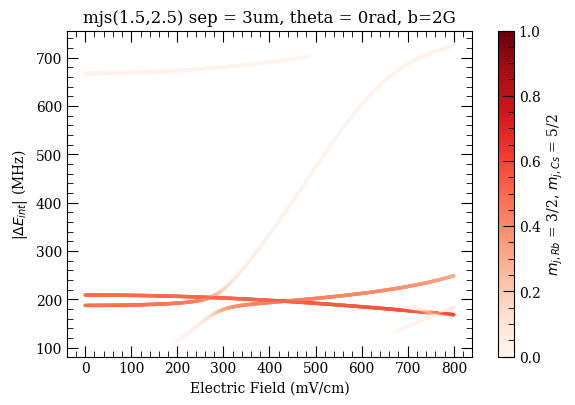

[np.float64(667.5810582637788), np.float64(187.60215783119202), np.float64(-209.1523711681366), np.float64(667.5814347267151), np.float64(187.6023678779602), np.float64(-209.15217280387878), np.float64(667.5825910568237), np.float64(187.60305976867676), np.float64(-209.15165042877197), np.float64(667.5845139026641), np.float64(187.60418725013733), np.float64(-209.15075206756592), np.float64(667.5872051715851), np.float64(187.60580134391785), np.float64(-209.1495327949524), np.float64(667.5906722545624), np.float64(187.60788750648499), np.float64(-209.1479778289795), np.float64(667.5949056148529), np.float64(187.61042022705084), np.float64(-209.14605712890625), np.float64(667.5999093055726), np.float64(187.61341452598572), np.float64(-209.14378595352173), np.float64(667.6056826114655), np.float64(187.61686992645264), np.float64(-209.14116621017456), np.float64(667.6122245788573), np.float64(187.62078857421875), np.float64(-209.13819670677185), np.float64(667.6195380687714), np.float64(1

In [203]:
import os
figpath = fr'C:\\Users\\tommy\\OneDrive - Durham University\\level 4 Project\\Figures\\interesting channels\\{atom1}{atom2}\\{n1_0}{orbs[l1_0]}{j1_0} {n2_0}{orbs[l2_0]}{j2_0}\\energy electric\\inter intra\\corrected\\'
if not os.path.exists(figpath):
    os.makedirs(figpath)
# ax.set_ylim(-0.01, 0.01)
datapath = fr'C:\\Users\\tommy\\OneDrive - Durham University\\level 4 Project\\Data\\interesting channels\\{atom1}{atom2}\\{n1_0}{orbs[l1_0]}{j1_0} {n2_0}{orbs[l2_0]}{j2_0}\\energy electric\\inter intra\\'

import os
datapath_field = fr'C:\\Users\\tommy\\OneDrive - Durham University\\level 4 Project\\Data\\interesting channels\\{atom1}{atom2}\\{n1_0}{orbs[l1_0]}{j1_0} {n2_0}{orbs[l2_0]}{j2_0}\\energy_electric\\inter intra\\field-corrected\\'
if not os.path.exists(datapath_field + 'inter'):
    os.makedirs(datapath_field + 'inter')
if not os.path.exists(datapath_field + 'intra Rb'):
    os.makedirs(datapath_field + 'intra Rb')
if not os.path.exists(datapath_field + 'intra Cs'):
    os.makedirs(datapath_field + 'intra Cs')

prop_cycle = plt.rcParams['axes.prop_cycle']
colours = prop_cycle.by_key()['color']

# system_atom = system_atom_dict[efield]
thetas = [0]
print(thetas)
b=2
r = 3
for theta in thetas:
    for mj1 in mj1_0s[-1:]:
        for mj2 in mj2_0s[-1:]:
            # print(overlapped_inter)
            overlapped_inter = pd.read_csv(datapath + f'inter\\mjs ({mj1}, {mj2}), theta {theta}, r {r}um, b {b}G.csv')
            overlapped_inter_big = pd.read_csv(datapath + f'inter\\mjs ({mj1}, {mj2}), theta {theta}, r {5000}um, b {b}G.csv')
            # overlapped_intra_Rb = pd.read_csv(datapath + f'intra Rb\\mjs ({mj1}, {mj1}), theta {theta}, r {r}um, b {b}G.csv')
            # overlapped_intra_Rb_big = pd.read_csv(datapath + f'inter\\mjs ({mj1}, {mj1}), theta {theta}, r {5000}um, b {b}G.csv')
            # overlapped_intra_Cs = pd.read_csv(datapath + f'intra Cs\\mjs ({mj2}, {mj2}), theta {theta}, r {r}um, b {b}G.csv')
            # overlapped_intra_Cs_big = pd.read_csv(datapath + f'inter\\mjs ({mj2}, {mj2}), theta {theta}, r {5000}um, b {b}G.csv')
            print(len(overlapped_inter), len(overlapped_inter_big))

            fig, ax = plt.subplots(ncols=1, figsize=(6, 4))
            ax.set_ylabel(fr"|$\Delta E_{{int}}$| ({energy_unit})")
            ax.set_xlabel(f"Electric Field (mV/cm)")
            plt.tight_layout()
            plt.title(fr'mjs({mj1},{mj2}) sep = {r}um, theta = {np.round(theta,2)}rad, b={b}G')
            energy_lim = abs(defect + defect*2)
            offset=defect/2
            min_energy = -energy_lim+offset
            max_energy = energy_lim+offset
            # plt.ylim(min_energy, max_energy)
            # plt.ylim(0,1)
            # for x, es in zip(rs, energies_inter):
            #     plt.plot([x] * len(es), es, c='.7', ls="None", marker=".", ms=1, zorder=-1)
            # ax.set_rticks([])
            # ax.set_thetagrids([])
            # ax.set_rlim([0,.5])
            min_overlap = 0.0
            energies = {'energy' : [], 'e' : [], 'overlap' : []}
            # print(overlapped_inter['theta'])
            if len(overlapped_inter) > 0:
                e = overlapped_inter['e'][0]
                # 1. Map b to energy from the 'big' dataset for O(1) lookup
                # This handles the "search" part instantly
                big_lookup = dict(zip(overlapped_inter_big['e'], overlapped_inter_big['energy']))
                overlap_lookup = dict(zip(overlapped_inter['e'], overlapped_inter['overlap']))

                # 2. Iterate through every single item in the original small dataset
                for j, e in enumerate(overlapped_inter['e']):
                    current_energy = overlapped_inter['energy'][j]
                    current_overlap = overlapped_inter['overlap'][j]
                    # 3. Check if this e exists in our big lookup table
                    if current_overlap >= min_overlap:
                        if e in big_lookup:
                            
                            # Subtract if match found
                            diff = current_energy - big_lookup[e]
                            energies['energy'].append(diff)
                        
                        
                    # Always append these to keep lengths aligned
                        energies['e'].append(e)
                        energies['overlap'].append(overlapped_inter['overlap'][j])
                

                scat = plt.scatter(
                    1000*np.array(energies['e']),
                    abs(np.array(energies['energy'])),
                    c=energies['overlap'],
                    s=10,
                    vmin=0,
                    vmax=1,
                    marker='.',
                    cmap = 'Reds'
                )
                plt.colorbar(scat, ax=ax, label=fr"$m_{{j,Rb}}$ = {int(mj1*2)}/2, $m_{{j,Cs}}$ = {int(mj2*2)}/2")

                # energies_Rb = {'energy' : [], 'b' : [], 'overlap' : []}
                # big_lookup = dict(zip(overlapped_intra_Rb_big['b'], overlapped_intra_Rb_big['energy']))
                # overlap_lookup = dict(zip(overlapped_intra_Rb['b'], overlapped_intra_Rb['overlap']))

                # # 2. Iterate through every single item in the original small dataset
                # for j, b in enumerate(overlapped_intra_Rb['b']):
                #     current_energy = overlapped_intra_Rb['energy'][j]
                #     current_overlap = overlapped_intra_Rb['overlap'][j]
                #     # 3. Check if this b exists in our big lookup table
                #     if current_overlap >= min_overlap:
                #         if b in big_lookup:
                            
                #             # Subtract if match found
                #             diff = current_energy - big_lookup[b]
                #             energies_Rb['energy'].append(diff)
                        
                        
                #     # Always append these to keep lengths aligned
                #         energies_Rb['b'].append(b)
                #         energies_Rb['overlap'].append(overlapped_intra_Rb['overlap'][j])

                # scat = plt.scatter(
                #     np.radians(energies_Rb['b']),
                #     abs(np.array(energies_Rb['energy'])),
                #     c=energies_Rb['overlap'],
                #     s=10,
                #     vmin=0,
                #     vmax=1,
                #     marker='.',
                #     cmap = 'Blues'
                # )

                # energies_Cs = {'energy' : [], 'b' : [], 'overlap' : []}
                # big_lookup = dict(zip(overlapped_intra_Cs_big['b'], overlapped_intra_Cs_big['energy']))
                # overlap_lookup = dict(zip(overlapped_intra_Cs['b'], overlapped_intra_Cs['overlap']))

                # # 2. Iterate through every single item in the original small dataset
                # for j, b in enumerate(overlapped_intra_Cs['b']):
                #     current_energy = overlapped_intra_Cs['energy'][j]
                #     current_overlap = overlapped_intra_Cs['overlap'][j]
                #     # 3. Check if this b exists in our big lookup table
                #     if current_overlap >= min_overlap:
                #         if b in big_lookup:
                            
                #             # Subtract if match found
                #             diff = current_energy - big_lookup[b]
                #             energies_Cs['energy'].append(diff)
                        
                        
                #     # Always append these to keep lengths aligned
                #         energies_Cs['b'].append(b)
                #         energies_Cs['overlap'].append(overlapped_intra_Cs['overlap'][j])
                # scat = plt.scatter(
                #     np.radians(energies_Cs['b']),
                #     abs(np.array(energies_Cs['energy'])),
                #     c=energies_Cs['overlap'],
                #     s=10,
                #     vmin=0,
                #     vmax=1,
                #     marker='.',
                #     cmap = 'Greens'
                # )
                plt.show()
                # plt.hlines((defect), xmin=magnetic_fields[0], xmax=magnetic_fields[-1], color='red', linestyle='dashed')
                pd.DataFrame(energies).to_csv(datapath_field + f'inter\\mjs ({mj1}, {mj2}), theta {theta}deg, r {r}um, b{b}G.csv')
                # pd.DataFrame(energies_Rb).to_csv(datapath_field + f'intra Rb\\mjs ({mj1}, {mj1}), theta {theta}deg, r {r}um, b{b}G.csv')
                # pd.DataFrame(energies_Cs).to_csv(datapath_field + f'intra Cs\\mjs ({mj2}, {mj2}), theta {theta}deg, r {r}um, b{b}G.csv')
                fig.savefig(figpath + f'sep {r}um b{np.round(b,3)}G b{b}G mjs{mj1},{mj2} theta {theta}deg.png')
                plt.close()
                print(energies['energy'])

1122 1000


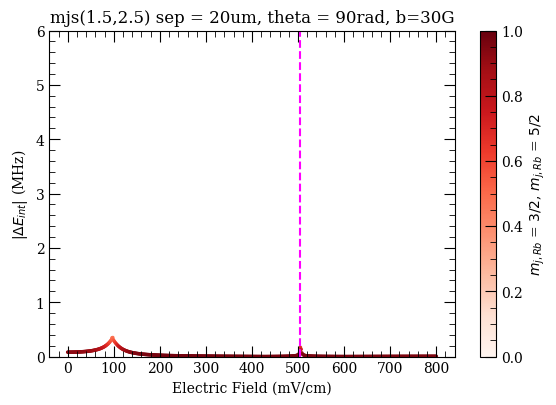

0      0.080752
1      0.080772
2      0.080831
3      0.080929
4      0.081067
         ...   
497    0.004858
498    0.004893
499    0.004928
500    0.004966
501    0.004986
Name: energy, Length: 502, dtype: float64
0.5050100200400801


In [177]:
mj1, mj2 = 3/2, 5/2
b=30
theta = 90
r=20
energies = pd.read_csv(datapath_field + f'inter\\mjs ({mj1}, {mj2}), theta {theta}deg, r {r}um, b{b}G.csv')

print(len(overlapped_inter), len(overlapped_inter_big))

fig, ax = plt.subplots(ncols=1, figsize=(6, 4))
ax.set_ylabel(fr"|$\Delta E_{{int}}$| ({energy_unit})")
ax.set_xlabel(f"Electric Field (mV/cm)")
plt.tight_layout()
plt.title(fr'mjs({mj1},{mj2}) sep = {r}um, theta = {np.round(theta,2)}rad, b={b}G')
energy_lim = abs(defect + defect*2)
offset=defect/2
min_energy = -energy_lim+offset
max_energy = energy_lim+offset
# plt.ylim(min_energy, max_energy)
plt.ylim(0,6)
# plt.xlim(0,100)

# for x, es in zip(rs, energies_inter):
#     plt.plot([x] * len(es), es, c='.7', ls="None", marker=".", ms=1, zorder=-1)
# ax.set_rticks([])
# ax.set_thetagrids([])
# ax.set_rlim([0,.5])
# print(max(energies['energy']))

# print(list(energies['energy']).index(max(energies['energy'])))
cross = energies['e'][list(energies['overlap']).index(min(energies['overlap'][100:]-.5)+.5)]
plt.axvline(x=cross*1e3, color='magenta', linestyle='dashed', label=f'Main resonance at {np.round(cross*1e3,2)} mV/cm')
scat = plt.scatter(
    1e3 * np.array(energies['e']),
    abs(np.array(energies['energy'])),
    c=energies['overlap'],
    s=10,
    vmin=0,
    vmax=1,
    marker='.',
    cmap = 'Reds'
)
plt.colorbar(scat, ax=ax, label=fr"$m_{{j,Rb}}$ = ${int(mj1*2)}/2$, $m_{{j,Rb}}$ = ${int(mj2*2)}/2$")
plt.show()
# plt.hlines((defect), xmin=magnetic_fields[0], xmax=magnetic_fields[-1], color='red', linestyle='dashed')
pd.DataFrame(energies).to_csv(datapath_field + f'inter\\mjs ({mj1}, {mj2}), theta {theta}deg, r {r}um, b {np.round(b,3)}G.csv')
fig.savefig(figpath + f'sep {r}um b{np.round(b,3)}G theta {theta}deg mjs{mj1},{mj2} min_o = {min_overlap}.png')
plt.close()
print(energies['energy'])
pos=[]
neg=[]


print(cross)

1122 1000
1122 1000
1122 1000


C:\Users\tommy\AppData\Local\Temp\ipykernel_12632\4202113613.py:26: UserWarning: No data for colormapping provided via 'c'. Parameters 'vmin', 'vmax' will be ignored
  scat = plt.scatter(


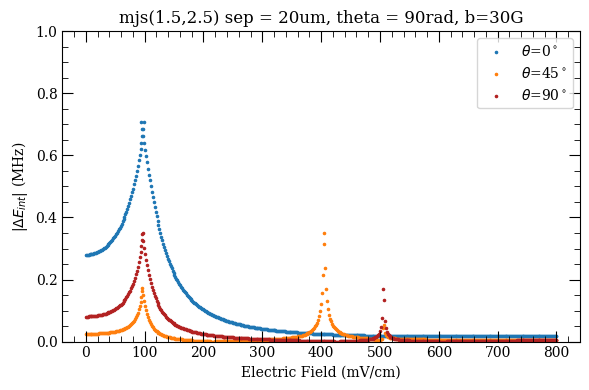

0      0.080752
1      0.080772
2      0.080831
3      0.080929
4      0.081067
         ...   
497    0.004858
498    0.004893
499    0.004928
500    0.004966
501    0.004986
Name: energy, Length: 502, dtype: float64
0.0977955911823647
-0.03045412266016778


In [169]:
mj1, mj2 = 3/2, 5/2
b=30
thetas=[0,45,90]
r=20
colours = ['tab:blue', 'tab:orange', 'firebrick']
fig, ax = plt.subplots(ncols=1, figsize=(6, 4))
ax.set_ylabel(fr"|$\Delta E_{{int}}$| ({energy_unit})")
ax.set_xlabel(f"Electric Field (mV/cm)")

for colour, theta in zip(colours, thetas):
    energies = pd.read_csv(datapath_field + f'inter\\mjs ({mj1}, {mj2}), theta {theta}deg, r {r}um, b{b}G.csv')

    print(len(overlapped_inter), len(overlapped_inter_big))

    
    plt.tight_layout()
    plt.title(fr'mjs({mj1},{mj2}) sep = {r}um, theta = {np.round(theta,2)}rad, b={b}G')
    energy_lim = abs(defect + defect*2)
    offset=defect/2
    min_energy = -energy_lim+offset
    max_energy = energy_lim+offset
    plt.ylim(0,1)



    scat = plt.scatter(
        1e3 * np.array(energies['e']),
        abs(np.array(energies['energy'])),
        c=colour,
        s=10,
        vmin=0,
        vmax=1,
        marker='.', label = fr'$\theta$={theta}$^\circ$'
    )
plt.legend()
# plt.colorbar(scat, ax=ax, label=fr"$m_{{j,Rb}}$ = ${int(mj1*2)}/2$, $m_{{j,Rb}}$ = ${int(mj2*2)}/2$")
plt.show()
# plt.hlines((defect), xmin=magnetic_fields[0], xmax=magnetic_fields[-1], color='red', linestyle='dashed')
pd.DataFrame(energies).to_csv(datapath_field + f'inter\\mjs ({mj1}, {mj2}), theta {theta}deg, r {r}um, b {np.round(b,3)}G.csv')
fig.savefig(figpath + f'sep {r}um b{np.round(b,3)}G theta {theta}deg mjs{mj1},{mj2} min_o = {min_overlap}.png')
plt.close()
print(energies['energy'])
pos=[]
neg=[]

print(energies['e'][list(energies['overlap']).index(min(energies['overlap']-.5)+.5)])
cross=min(energies['overlap']-.5)
print(cross)

In [41]:
import os
datapath = fr'C:\\Users\\tommy\\OneDrive - Durham University\\level 4 Project\\Data\\interesting channels\\{atom1}{atom2}\\{n1_0}{orbs[l1_0]}{j1_0} {n2_0}{orbs[l2_0]}{j2_0}\\energy electric\\inter intra\\'

figpath = fr'C:\\Users\\tommy\\OneDrive - Durham University\\level 4 Project\\Figures\\interesting channels\\{atom1}{atom2}\\{n1_0}{orbs[l1_0]}{j1_0} {n2_0}{orbs[l2_0]}{j2_0}\\energy electric\\inter intra\\asymmetry\\'
if not os.path.exists(figpath):
    os.makedirs(figpath)
# ax.set_ylim(-0.01, 0.01)

prop_cycle = plt.rcParams['axes.prop_cycle']
colours = prop_cycle.by_key()['color']

# system_atom = system_atom_dict[efield]

theta = 0
b=0.0
for theta in thetas:
    for mj1 in mj1_0s:
        for mj2 in mj2_0s:
            corrected_inter = pd.read_csv(datapath_field + f'inter\\mjs ({mj1}, {mj2}), theta {theta}deg, r {r}um.csv')
            corrected_intra_Rb = pd.read_csv(datapath_field + f'intra Rb\\mjs ({mj1}, {mj1}), theta {theta}deg, r {r}um.csv')
            corrected_intra_Cs = pd.read_csv(datapath_field + f'intra Cs\\mjs ({mj2}, {mj2}), theta {theta}deg, r {r}um.csv')

            
            big_lookup = dict(zip(corrected_intra_Rb['b'], corrected_intra_Rb['energy']))
            third_lookup = dict(zip(corrected_intra_Cs['b'], corrected_intra_Cs['energy']))

            # 2. Initialize your results (will be same length as the loop source)
            assym = {
            'energy': [],
            'b': [],
            'overlap': []
            }

            # 3. Iterate through EVERY element of the PRIMARY dataset
            for i, b in enumerate(corrected_inter['b']):
                current_energy = corrected_inter['energy'][i]

                # Use .get(b, 0) to "safely" grab the value. 
                # If the b doesn't exist in that specific set, it defaults to 0.
                val_big = big_lookup.get(b, 0)
                val_third = third_lookup.get(b, 0)

                # 4. Perform your manipulation (e.g., subtracting both from the original)
                final_calc = current_energy/np.sqrt(val_big * val_third)

                # 5. Append to keep the output arrays aligned with the input
                assym['energy'].append(final_calc)
                assym['b'].append(b)
                assym['overlap'].append(corrected_inter['overlap'][i])
                    

            fig = plt.figure()
            plt.scatter(abs(np.array(assym['b'])), abs(np.array(assym['energy'])), c=assym['overlap'], cmap='Greens', marker= '.')
            plt.colorbar(label = fr'overlap with $m_{{j,Rb}} = {int(2*mj1)}/2$, $m_{{j,Cs}} = {int(2*mj2)}/2$')
            plt.xlabel(r'Electric field (V/cm)')
            plt.ylabel(r'Asymmetry factor $\zeta$')
            plt.title(f'asym {orbs[l1_0]}{j1_0}mj{mj1} {orbs[l2_0]}{j2_0}mj{mj2}, r {r}um, theta {theta}deg')
            plt.show()
            fig.savefig(figpath + f'mjs {mj1}{mj2}, theta {theta}, r {r}um, e{e}Vcm, mjs{mj1},{mj2}.png')
            plt.close(fig)


KeyError: 'b'

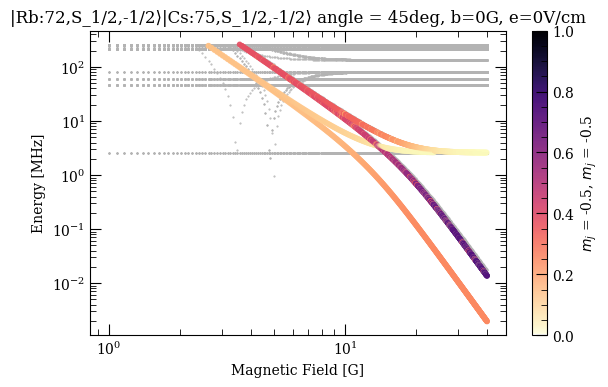

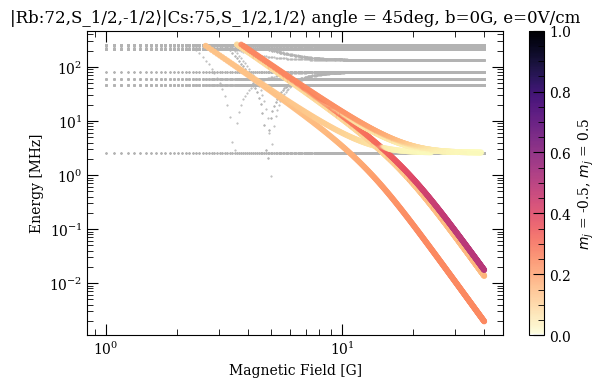

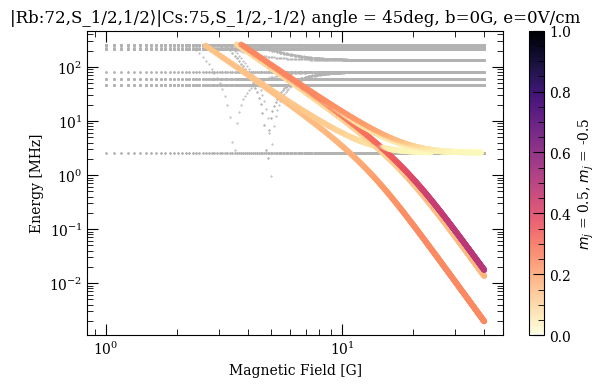

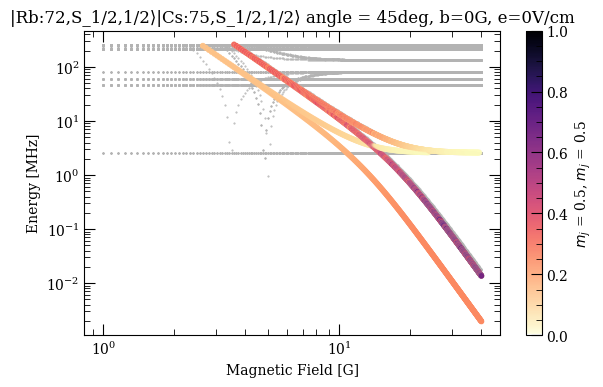

In [ ]:
import os
figpath = fr'C:\\Users\\tommy\\OneDrive - Durham University\\level 4 Project\\Figures\\separations\\overlapped\\{atom1}{atom2}\\{orbs[l1_0]}{orbs[l2_0]}\\to {orbs[l1_1]}{orbs[l2_1]}\\j1j2({j1_0},{j2_0})\\log\\'
if not os.path.exists(figpath):
    os.makedirs(figpath)

for mj1 in mj1_0s:
    for mj2 in mj2_0s:

        ket1, ket2 = pi.KetAtom(atom1, n=n1_0, l=l1_0, j=j1_0, m=mj1), pi.KetAtom(atom2, n=n2_0, l=l2_0, j=j2_0, m=mj2)
        overlaps1 = [system.get_eigenbasis().get_overlaps([ket1, ket2]) for system in system_pairs]


        # plt.axhline(defect, color='r', linewidth=2, alpha=1, linestyle='dotted')
        fig, ax = plt.subplots(ncols=1, figsize=(6, 4))
        ax.set_yscale('log')
        ax.set_xscale('log')
        ax.set_xlabel("E_z (mV/cm)")
        ax.set_ylabel(f"Energy ({energy_unit})")
        ax.set_title(fr'separations $\mu$m')
        plt.tight_layout()
        plt.title(fr'{str(ket1)}{str(ket2)} angle = {angle}deg, b={b}G, e={e}V/cm')
        energy_lim = abs(defect + defect*2)
        offset=defect/2
        min_energy = -energy_lim+offset
        max_energy = energy_lim+offset
        # plt.ylim(min_energy, max_energy)
        # plt.xlim(2, 2.7)
        plt.ylabel(f"Energy [{energy_unit}]")
        plt.xlabel("electric Field [V/cm]")
        # ax.plot(e_fields_sub, energies)

        for x, es in zip(rs, energies):
            plt.plot([x] * len(es), abs(es), c='.7', ls="None", marker=".", ms=1, zorder=-1)
        min_overlap = 0.000
        for x, es, os in zip(rs, energies, overlaps1):
            inds = np.argwhere(os > min_overlap).flatten()
            inds = inds[np.argsort(os[inds])]
            if len(inds) > 0:
                scat = plt.scatter(
                    [x] * len(es[inds]),
                    abs(es[inds]),
                    c=os[inds],
                    s=10,
                    vmin=0,
                    vmax=1,
                    cmap=alphamagma,
                )
        fig.colorbar(scat, ax=ax, label=fr"$m_j$ = {mj1}, $m_j$ = {mj2}")
        # plt.hlines((defect), xmin=magnetic_fields[0], xmax=magnetic_fields[-1], color='red', linestyle='dashed')
        fig.savefig(figpath + f'level pairstate deg{angle} b{b}G e{e}Vcm mjs{mj1},{mj2}.png')


{'mjs0-0.5-0.5': [], 'mjs0-0.50.5': [], 'mjs00.5-0.5': [], 'mjs00.50.5': []}


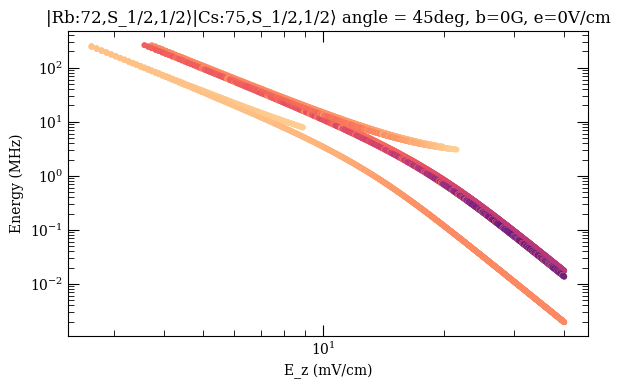

In [10]:
min_overlap = 0.1
energies_dict_0 = {f'mjs0{mj1_0}{mj2_0}': [] for mj1_0 in mj1_0s for mj2_0 in mj2_0s}
print(energies_dict_0)
fig, ax = plt.subplots(ncols=1, figsize=(6, 4))
ax.set_yscale('log')
ax.set_xscale('log')
ax.set_xlabel("E_z (mV/cm)")
ax.set_ylabel(f"Energy ({energy_unit})")
ax.set_title(fr'separations $\mu$m')
plt.tight_layout()
plt.title(fr'{str(ket1)}{str(ket2)} angle = {angle}deg, b={b}G, e={e}V/cm')

for mj1_0 in mj1_0s:
    for mj2_0 in mj2_0s:
        ket1_0 = pi.KetAtom(atom1, n=n1_0, l=l1_0, j=j1_0, m=mj1_0)
        ket2_0 = pi.KetAtom(atom2, n=n2_0, l=l2_0, j=j2_0, m=mj2_0)
        overlaps1 = [system.get_eigenbasis().get_overlaps([ket1_0, ket2_0]) for system in system_pairs]

        energies1=[]
        ds=[]
        for x, es, os in zip(rs, energies, overlaps1):
            inds = np.argwhere(os > min_overlap).flatten()
            inds = inds[np.argsort(os[inds])]
            if len(inds) > 0:
                scat = plt.scatter(
                    [x] * len(es[inds]),
                    abs(es[inds]),
                    c=os[inds],
                    s=10,
                    vmin=0,
                    vmax=1,
                    cmap=alphamagma,
                )
                energies1 = np.append(energies1, es[inds])
                ds = np.append(ds, [x] * len(es[inds]))
        energies_dict_0[f'rs{mj1_0}{mj2_0}'] = ds
        energies_dict_0[f'mjs0{mj1_0}{mj2_0}'] = energies1

[ 2.64128257  2.64128257  2.71943888 ... 39.92184369 40.
 40.        ]
182 182
[[445056.6512226]]
[117.84927326]


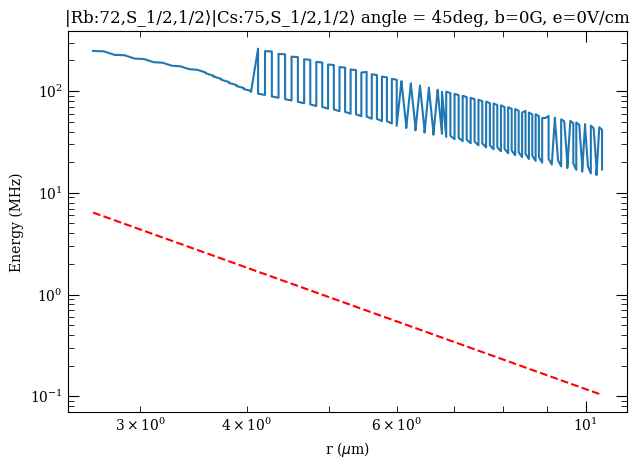

In [18]:
import os
figpath = fr'C:\\Users\\tommy\\OneDrive - Durham University\\level 4 Project\\Figures\\interesting channels\\{atom1}{atom2}\\{n1_0}{orbs[l1_0]}{j1_0} {n2_0}{orbs[l2_0]}{j2_0}\\separations\\log fitted\\'
if not os.path.exists(figpath):
    os.makedirs(figpath)

datapath = fr'C:\\Users\\tommy\\OneDrive - Durham University\\level 4 Project\\data\\interesting channels\\{atom1}{atom2}\\{n1_0}{orbs[l1_0]}{j1_0} {n2_0}{orbs[l2_0]}{j2_0}\\separations\\log fitted\\'
if not os.path.exists(datapath):
    os.makedirs(datapath)

def func(r, c):
    return c/(r)**3 
rmax=10.5
mj1_0, mj2_0 = -1/2, -1/2
ds = energies_dict_0[f'rs{mj1_0}{mj2_0}']
print(ds)
ds = ds[np.argwhere(ds<rmax)].flatten()[::2]

energy = energies_dict_0[f'mjs0{mj1_0}{mj2_0}']
energy = energy[np.argwhere(ds<rmax)].flatten()
print(len(ds), len(energy))
popt, pcov = scipy.optimize.curve_fit(func, ds, energy)
fig, ax = plt.subplots()
ax.set_yscale('log')
ax.set_xscale('log')
ax.set_xlabel(r"r ($\mu$m)")
ax.set_ylabel(f"Energy ({energy_unit})")
ax.set_title(fr'separations $\mu$m')
plt.tight_layout()
plt.title(fr'{str(ket1)}{str(ket2)} angle = {angle}deg, b={b}G, e={e}V/cm')

ax.plot(ds, abs(energy))
ax.plot(ds, abs(func(ds, *popt)), linestyle='dashed', color='red')
fig.savefig(figpath + f'deg{angle} b{b}G e{e}Vcm mjs{mj1_0},{mj2_0}.png')
print(pcov)
C3 = pd.DataFrame({'c3' : [popt[0]], 'error' : [np.sqrt(np.diag(pcov))[0]]})
C3.to_csv(datapath + f'deg{angle} b{b}G e{e}Vcm mjs{mj1_0},{mj2_0}.csv', index=False)

print(popt)